### Project Overview
This notebook performs an in-depth analysis of job seeker data, covering exploratory data analysis (EDA), statistical hypothesis testing, machine learning model development, and model interpretability.


### 1. Library Imports
This section imports all necessary Python libraries for data manipulation, visualization, statistical analysis, machine learning, and model interpretability.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import shap
import warnings
warnings.filterwarnings('ignore')

### 2. Data Loading and Initial Cleaning
We start by loading the dataset from `bdJobs303.csv` into a Pandas DataFrame. Missing values in key demographic and occupational columns are then removed to ensure data quality for subsequent analysis.

In [8]:
df = pd.read_csv('bdJobsCSE303.csv')
df = df.dropna(subset=['Age', 'Gender', 'Religion', 'Grouped Occupation', 'Occupation'])
print("Data loaded and initial cleaning complete. Displaying first 5 rows:")
display(df.head())

Data loaded and initial cleaning complete. Displaying first 5 rows:


,Job name,Company Name,Location,Experience,Education Qualification,Year,Deadline,Occupation,Age,Gender,Religion,Specific Major,Skills,Grouped Occupation
0,Senior Officer - Skills to Succeed (S2S),Save the Children,Dhaka,At least 10 year(s),"Master`s Degree in any subject, preferably in ...",2023.0,13-Apr,General Corporate,25,Male,Islam,Arts/Social Science,"MS Office, Communication, Teamwork, Report Wri...",Business Operations
1,Head of Grants; Global Resource Mobilisation &...,BRAC,Anywhere in Bangladesh,Na,Masters or equivalent degree in International ...,2023.0,13-Apr,General Corporate,22,Male,Islam,Business/Commerce,"MS Office, Communication, Teamwork, Report Wri...",Business Operations
2,???? ????? ?????????,BRAC,?????????? ?????? ??????,At least 1 year(s),?? ??? ??????? ?????? ?????????? ???? ????????...,2023.0,27-Mar,General Corporate,38,Male,Islam,Other/General,"MS Office, Communication, Teamwork, Report Wri...",Business Operations
3,PA To Managing Director,Fu-Wang Foods Ltd,Anywhere in Bangladesh,NaN,Graduation in Business,2023.0,13-Apr,General Corporate,26,Male,Islam,Business/Commerce,"MS Office, Communication, Teamwork, Report Wri...",Business Operations
4,Sr. Merchandiser for woven division,"Chori Co., Ltd. Dhaka Liaison Office",Uttara,Na,Minimum graduate from reputed university in an...,2023.0,13-Apr,General Corporate,27,Male,Hinduism,CSE/IT,"MS Office, Communication, Teamwork, Report Wri...",Business Operations


### 3. Exploratory Data Analysis (EDA)
This section visualizes various aspects of the dataset to understand distributions and relationships between key variables.

#### 3.1 Occupation Distribution
This bar chart shows the distribution of job seekers across different occupations, ordered from the most frequent to the least frequent.

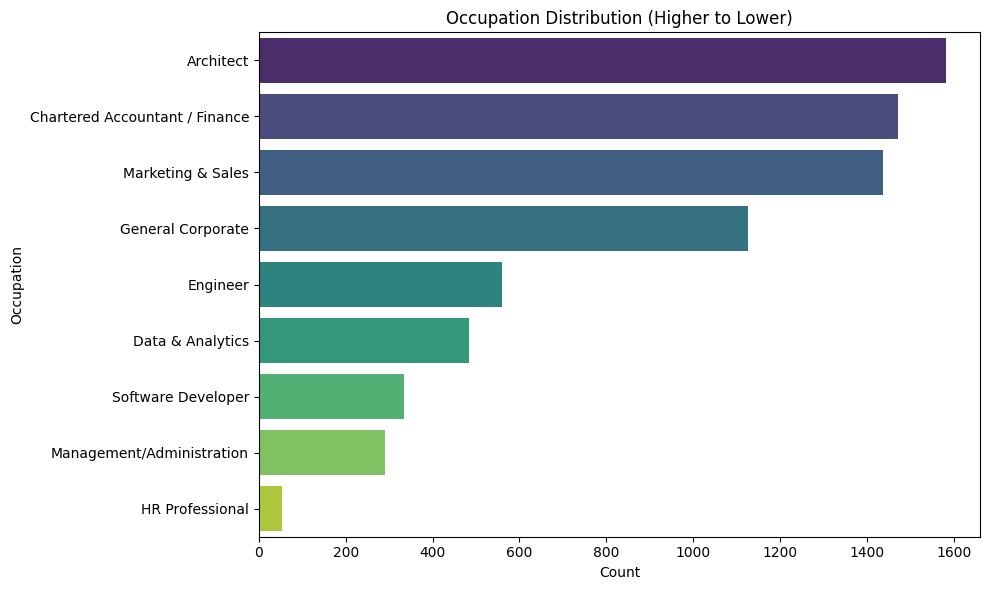

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(y='Occupation', data=df, order=df['Occupation'].value_counts().index, palette='viridis')
plt.title('Occupation Distribution (Higher to Lower)')
plt.xlabel('Count')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

#### 3.2 Age Interval Analysis
This histogram illustrates the age distribution of job seekers, providing insights into typical age ranges in the dataset.

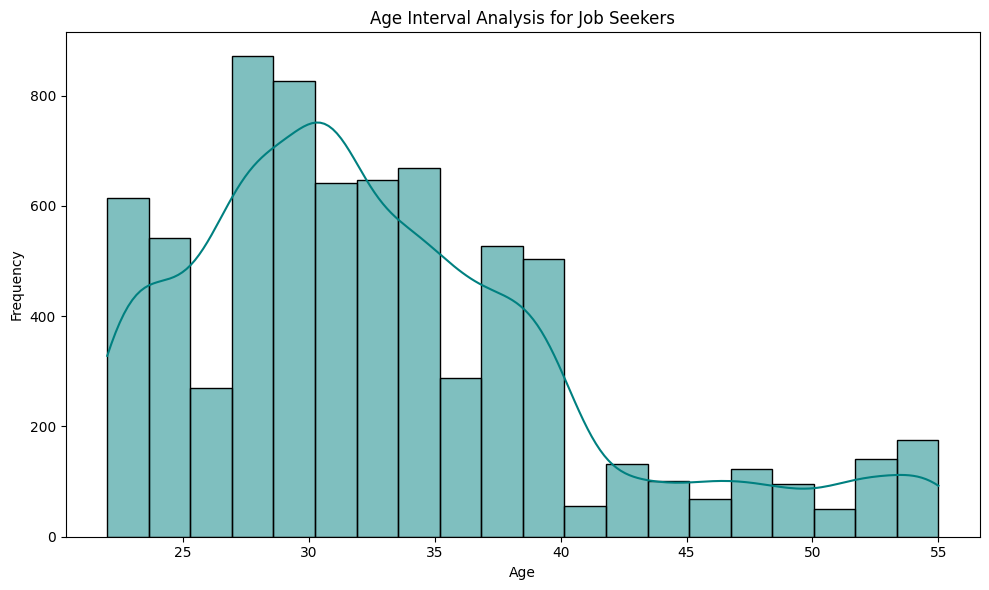

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True, color='teal')
plt.title('Age Interval Analysis for Job Seekers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### 3.3 Religion vs. Occupation Heatmap & Chi-Square Test
This heatmap visualizes the relationship between religion and grouped occupation categories. A Chi-Square test is performed to statistically assess if there's a significant association between these two categorical variables.

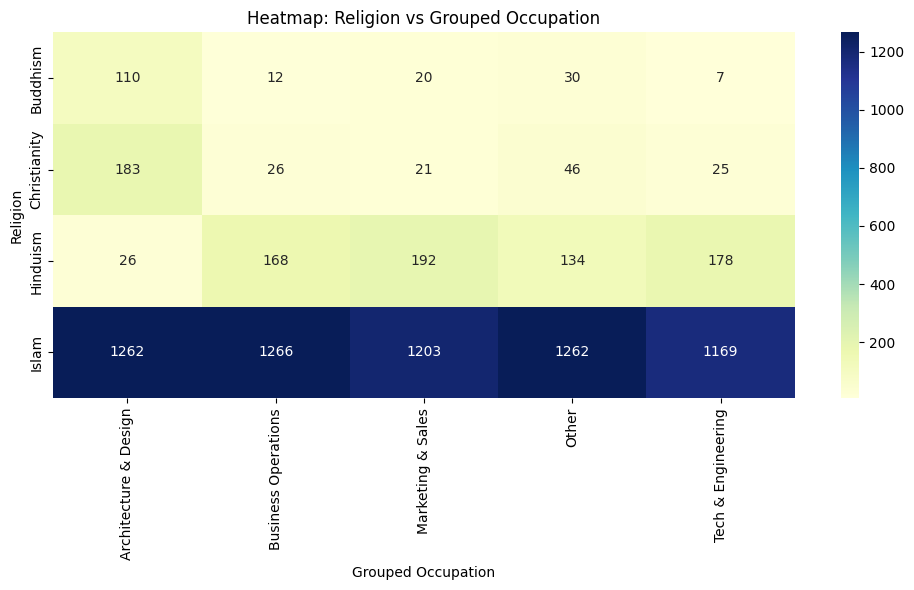


--- Chi-Square Test (Religion vs Occupation) ---
Null Hypothesis (H0): Religion and Occupation are independent.
Chi2 Stat: 609.7086, p-value: 8.9516e-123
Conclusion: Reject the null hypothesis. There is a significant association between Religion and Occupation.


In [11]:
plt.figure(figsize=(10,6))
cross_tab = pd.crosstab(df['Religion'], df['Grouped Occupation'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Religion vs Grouped Occupation')
plt.tight_layout()
plt.show()

# Chi-Square Hypothesis Test
chi2, p, dof, ex = chi2_contingency(cross_tab)
print(f"\n--- Chi-Square Test (Religion vs Occupation) ---")
print(f"Null Hypothesis (H0): Religion and Occupation are independent.")
print(f"Chi2 Stat: {chi2:.4f}, p-value: {p:.4e}")
if p < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant association between Religion and Occupation.")
else:
    print("Conclusion: Fail to reject the null hypothesis. Religion and Occupation are independent.")

#### 3.4 Gender Distribution per Occupation & T-Test
This countplot shows the gender distribution within each grouped occupation. Additionally, a T-test is conducted to compare the mean age between male and female job seekers, assessing for a significant difference.

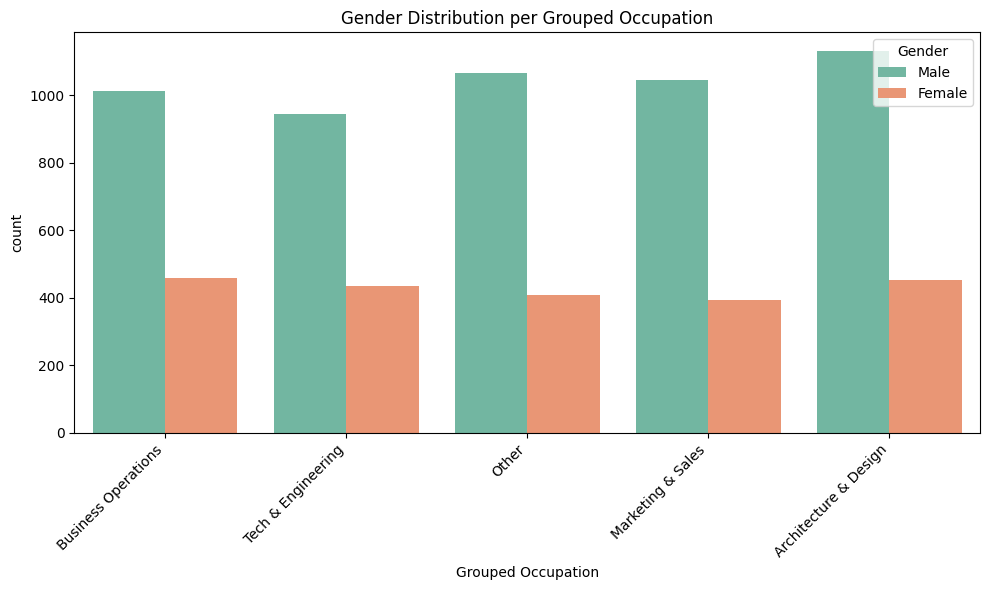


--- T-test (Age variance between Genders) ---
T-statistic: -7.5558, p-value: 4.6654e-14
Conclusion: Reject the null hypothesis. There is a significant difference in age between Genders.


In [12]:
plt.figure(figsize=(10,6))
sns.countplot(x='Grouped Occupation', hue='Gender', data=df, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Gender Distribution per Grouped Occupation')
plt.tight_layout()
plt.show()

# T-Test (Age variance between Genders)
male_age = df[df['Gender'] == 'Male']['Age']
female_age = df[df['Gender'] == 'Female']['Age']
t_stat, p_val = ttest_ind(male_age.dropna(), female_age.dropna())
print(f"\n--- T-test (Age variance between Genders) ---")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in age between Genders.")
else:
    print("Conclusion: Fail to reject the null hypothesis. No significant difference in age between Genders.")

### 4. Feature Engineering and Data Splitting
This section prepares the data for machine learning by encoding categorical features and splitting the dataset into training and testing sets using stratified sampling to maintain class balance.

#### 4.1 Label Encoding Categorical Features
Categorical features like 'Gender', 'Religion', 'Specific Major', 'Skills', and 'Grouped Occupation' are converted into numerical representations using Label Encoding, which is suitable for many machine learning algorithms. The `le_dict` stores the encoders for inverse transformation if needed.

In [13]:
le_dict = {}
ml_df = df[['Age', 'Gender', 'Religion', 'Specific Major', 'Skills', 'Grouped Occupation']].copy()
cat_cols = ['Gender', 'Religion', 'Specific Major', 'Skills', 'Grouped Occupation']

for col in cat_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    le_dict[col] = le

print("Label Encoding complete. Displaying first 5 rows of engineered data:")
display(ml_df.head())

Label Encoding complete. Displaying first 5 rows of engineered data:


,Age,Gender,Religion,Specific Major,Skills,Grouped Occupation
0,25,1,3,0,5,1
1,22,1,3,1,5,1
2,38,1,3,6,5,1
3,26,1,3,1,5,1
4,27,1,2,2,5,1


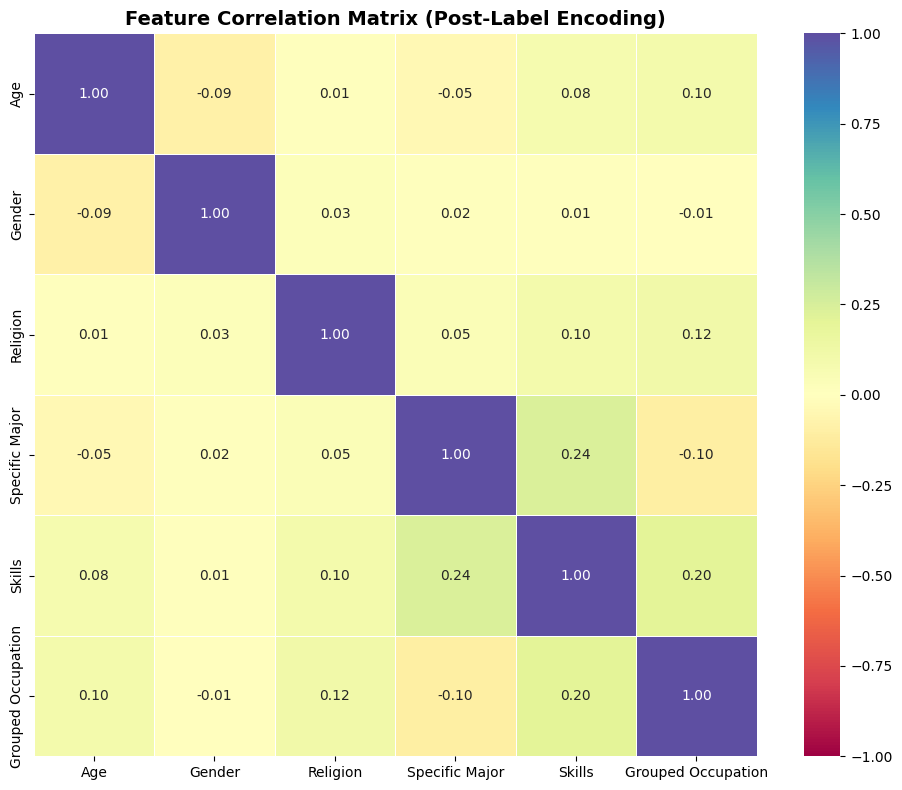

In [14]:
plt.figure(figsize=(10, 8))
# Calculate Pearson Correlation on the mathematically encoded dataframe
corr_matrix = ml_df.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Spectral', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Post-Label Encoding)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 4.2 Define Features (X) and Target (y)
The dataset is separated into features (X), which are the input variables, and the target variable (y), which is 'Grouped Occupation' for classification tasks.

In [15]:
X = ml_df.drop('Grouped Occupation', axis=1)
y = ml_df['Grouped Occupation']

print("Features (X) and Target (y) defined. X shape: {}, y shape: {}".format(X.shape, y.shape))

Features (X) and Target (y) defined. X shape: (7340, 5), y shape: (7340,)


#### 4.3 Stratified Train-Test Split
The data is split into training (80%) and testing (20%) sets. Stratified sampling is used to ensure that the proportion of each 'Grouped Occupation' class is maintained in both training and testing sets, which is crucial for balanced evaluation in multi-class classification.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n--- Stratified Sampling Info ---")
print(f"Train set size: {len(X_train)} | Test set size: {len(X_test)}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")


--- Stratified Sampling Info ---
Train set size: 5872 | Test set size: 1468
Train target distribution:
Grouped Occupation
0    0.215429
1    0.200613
3    0.200443
2    0.195674
4    0.187841
Name: proportion, dtype: float64
Test target distribution:
Grouped Occupation
0    0.215259
3    0.200954
1    0.200272
2    0.195504
4    0.188011
Name: proportion, dtype: float64


<Figure size 1000x600 with 0 Axes>

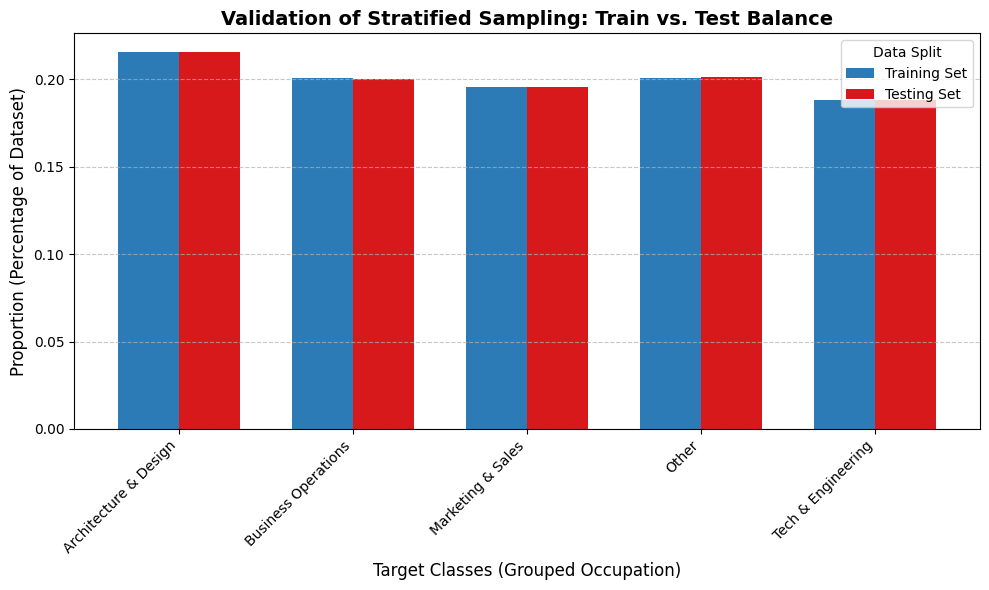

In [17]:
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

# Combine into a single DataFrame for plotting
dist_df = pd.DataFrame({'Training Set': train_dist, 'Testing Set': test_dist})

# Reverse the Label Encoding to show real names on the graph (e.g., "Engineering" instead of "2")
class_names = le_dict['Grouped Occupation'].inverse_transform(dist_df.index)
dist_df.index = class_names

# Plot the dual bar chart
plt.figure(figsize=(10, 6))
dist_df.plot(kind='bar', color=['#2c7bb6', '#d7191c'], figsize=(10, 6), width=0.7)
plt.title('Validation of Stratified Sampling: Train vs. Test Balance', fontsize=14, fontweight='bold')
plt.ylabel('Proportion (Percentage of Dataset)', fontsize=12)
plt.xlabel('Target Classes (Grouped Occupation)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Data Split')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5. Machine Learning Model Training & Evaluation (Initial Models)
This section trains and evaluates several machine learning models for both regression (predicting Age) and classification (predicting Grouped Occupation).

#### 5.1 Linear Regression (Predicting Age)
A Linear Regression model is trained to predict the 'Age' of job seekers based on other demographic and skill features. Its performance is evaluated using Mean Squared Error (MSE) and R-squared (R2 Score).

In [18]:
lr = LinearRegression()
X_lin = ml_df.drop('Age', axis=1)
y_lin = ml_df['Age']
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
lr.fit(X_train_lin, y_train_lin)
y_pred_lin = lr.predict(X_test_lin)
print(f"\n--- Linear Regression Performance (Target: Age) ---")
print(f"MSE: {mean_squared_error(y_test_lin, y_pred_lin):.4f} | R2 Score: {r2_score(y_test_lin, y_pred_lin):.4f}")


--- Linear Regression Performance (Target: Age) ---
MSE: 59.6845 | R2 Score: 0.0232


#### 5.2 Logistic Regression (Predicting Grouped Occupation)
A Logistic Regression model is trained to classify the 'Grouped Occupation' based on the engineered features. Its accuracy is reported.

In [19]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print(f"\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")


--- Logistic Regression Performance ---
Accuracy: 0.8059


#### 5.3 Random Forest Classifier (Predicting Grouped Occupation)
A Random Forest Classifier, an ensemble learning method, is trained for the 'Grouped Occupation' classification task. Its accuracy is evaluated.

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


--- Random Forest Performance ---
Accuracy: 1.0000


#### 5.4 Confusion Matrix for Random Forest
This heatmap displays the confusion matrix for the Random Forest Classifier, showing the number of correct and incorrect predictions for each occupation class. This helps in understanding the model's performance in more detail than just accuracy.

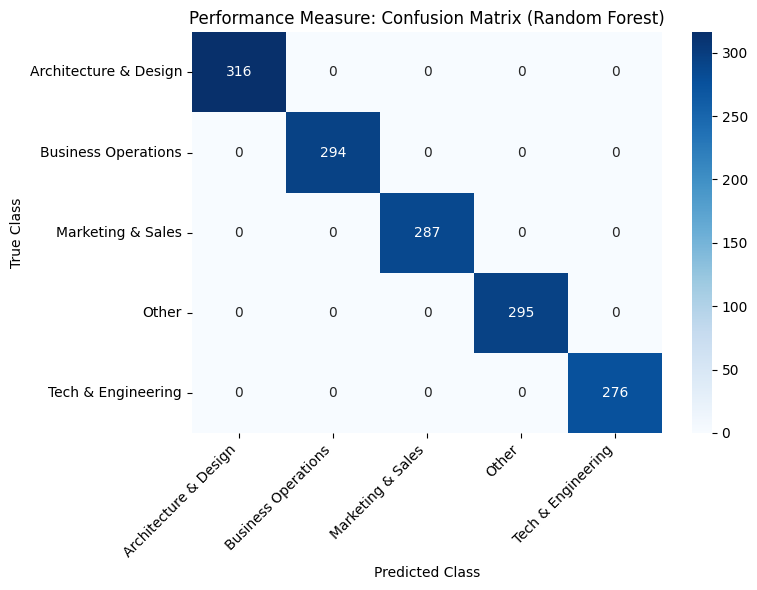

In [21]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_dict['Grouped Occupation'].classes_,
            yticklabels=le_dict['Grouped Occupation'].classes_)
plt.title('Performance Measure: Confusion Matrix (Random Forest)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
import ipywidgets as widgets
from IPython.display import display
from sklearn.datasets import make_classification # Import make_classification

# 1. A complex synthetic dataset (to guarantee overfitting happens)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                           n_redundant=2, n_repeated=0, class_sep=0.7, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Pre-calculate the model's performance for depths 1 through 20
max_depths = list(range(1, 21))
train_scores = []
test_scores = []

print("Training 20 Random Forest models in the background... Please wait a second.")
for depth in max_depths:
    # We keep n_estimators at 100 to isolate the effect of max_depth
    rf = RandomForestClassifier(max_depth=depth, n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))
print("Done! Use the slider below to explore.")
print("-" * 50)

# 3. the interactive visualization function
def plot_performance(current_depth):
    plt.figure(figsize=(10, 6))

    # Plot the curves
    plt.plot(max_depths, train_scores, label='Training Accuracy', color='royalblue', linewidth=2, marker='o')
    plt.plot(max_depths, test_scores, label='Test Accuracy (Unseen Data)', color='darkorange', linewidth=2, marker='s')

    # Draw a vertical line for the slider's current position
    plt.axvline(x=current_depth, color='crimson', linestyle='--', linewidth=2, label=f'Current Depth: {current_depth}')

    # Formatting the chart
    plt.title('Random Forest: The Overfitting Danger Zone', fontsize=14, fontweight='bold')
    plt.xlabel('Max Tree Depth (Complexity)', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.xticks(max_depths)
    plt.yticks(np.arange(0.5, 1.05, 0.05))
    plt.ylim(0.55, 1.05)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Display the exact numbers below the chart
    idx = current_depth - 1
    print(f"--- At Max Depth {current_depth} ---")
    print(f"Training Accuracy : {train_scores[idx]:.4f} (Model memorizing the data)")
    print(f"Test Accuracy     : {test_scores[idx]:.4f} (Model predicting new data)")

    if train_scores[idx] == 1.0:
        print("\n⚠️ WARNING: Model has hit 100% training accuracy. It is officially overfitting.")

# 4. Generate the interactive slider widget
depth_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=20,
    step=1,
    description='Max Depth:',
    continuous_update=False # Updates only when you release the mouse for better performance
)

# Bind the slider to the plot
widgets.interact(plot_performance, current_depth=depth_slider);

Training 20 Random Forest models in the background... Please wait a second.
Done! Use the slider below to explore.
--------------------------------------------------


interactive(children=(IntSlider(value=1, continuous_update=False, description='Max Depth:', max=20, min=1), Ou…

### 6. Advanced Experimental Design and Model Interpretability
This section delves into more advanced machine learning techniques, including cross-validation, hyperparameter tuning, feature importance analysis, and SHAP for model interpretability.

#### 6.1 K-Fold Cross Validation
5-Fold Stratified Cross-Validation is performed on the Random Forest model to assess its generalization performance and robustness across different subsets of the training data. This helps in getting a more reliable estimate of model performance than a single train-test split.

In [22]:
print("--- Running 5-Fold Cross Validation ---")
rf_base = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_base, X_train, y_train, cv=cv, scoring='accuracy')

print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})\n")

--- Running 5-Fold Cross Validation ---
CV Accuracy Scores: [0.99829787 1.         0.99914821 0.99914821 0.99914821]
Mean CV Accuracy: 0.9991 (+/- 0.0005)



#### 6.2 Hyperparameter Tuning with Grid Search
Grid Search is used to systematically search for the best combination of hyperparameters for the Random Forest Classifier. This optimization process aims to improve the model's performance.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# Assuming X has your features (Experience, Education) and y is 'Occupation'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Create the base model
tree_model = DecisionTreeClassifier(random_state=42)

# 2. Define the "Dials" you want to test (The Grid)
# The computer will test 5 depths and 3 split settings (5 x 3 = 15 different models!)
hyperparameter_grid = {
    'max_depth': [3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

# 3. (Grid Search)
print("Testing all 15 combinations of settings... Please wait.")
optimizer = GridSearchCV(estimator=tree_model, param_grid=hyperparameter_grid, cv=5, scoring='accuracy')
optimizer.fit(X_train, y_train)

#Results:
print("Optimization Complete!\n")
print(f"The best Hyperparameters are: {optimizer.best_params_}")
print(f"The highest Accuracy achieved was: {optimizer.best_score_:.4f}")

# optimized model to predict new data
best_model = optimizer.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f"Accuracy on unseen Test Data: {test_accuracy:.4f}")

Testing all 15 combinations of settings... Please wait.
Optimization Complete!

The best Hyperparameters are: {'max_depth': 10, 'min_samples_split': 2}
The highest Accuracy achieved was: 0.8150
Accuracy on unseen Test Data: 0.8450


#### 6.3 Feature Importance Analysis
This horizontal bar plot visualizes the relative importance of each feature in the best-tuned Random Forest model. It highlights which features contribute most to the model's predictions.

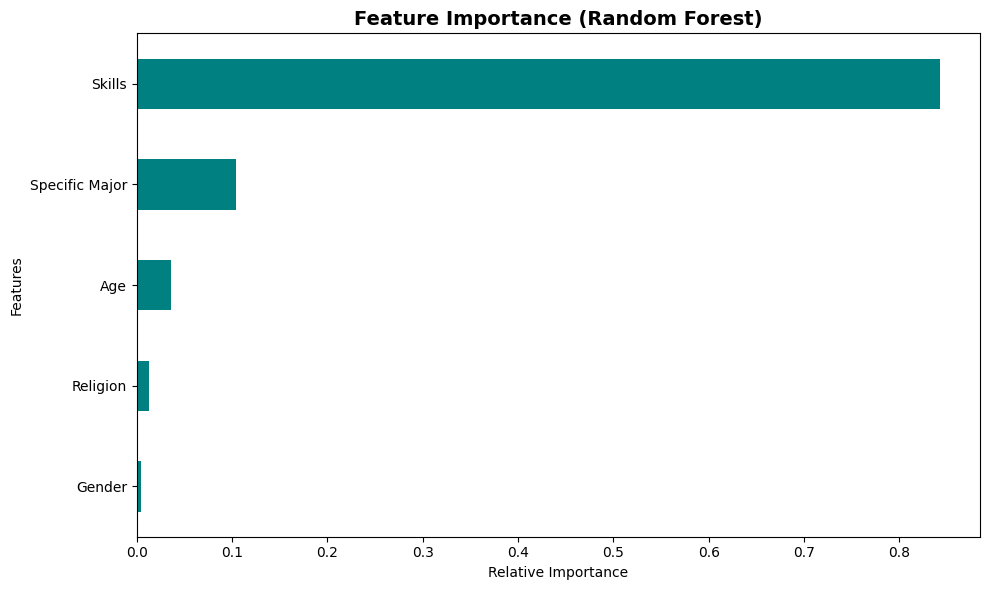

In [24]:
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

feat_imp.plot(kind='barh', color='teal')
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()